# Yb:YAG spectra

Reflection and transmission measurements for nominal 5, 10, and 15 at.% coated samples, with uncoated sample A3. The analysis uses paired-face reflection for coated-sample absorption and single-pass transmission for A3. Set A3's measured thickness in `A3_THICKNESS_MM` in the first code cell. Set the coated active-layer thicknesses in `THICKNESS_UM` immediately before the cross-section calculations and report. Reference-mirror response, coating geometry, and the simplified incoherent model limit absolute accuracy.

In [1]:
from pathlib import Path
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd()
if not (HERE / "reflection").exists():
    HERE = HERE / "research" / "ybyag_absorption_cross_section_2026-09-29"
if not (HERE / "reflection").exists():
    raise FileNotFoundError("Run the notebook from its folder or from the project root.")

A3_THICKNESS_MM = 0.509  # 509 µm, assigned to A3 from the user's uncoated 5% value.
A3_NOMINAL_YB_AT_PERCENT = 5.0
MIRROR_CSV = HERE / "aluminum_reference_nist_example.csv"
OPEN_AND_COATED_SIDES = {5: ("B", "A"), 10: ("A", "B"), 15: ("A", "B")}
YB_ION_DENSITY_PER_AT_PERCENT = 1.385e20  # cm^-3 per at.%
YAG_INDEX = 1.83
FRESNEL_R = ((YAG_INDEX - 1) / (YAG_INDEX + 1)) ** 2
COLORS = {5: "#4477AA", 10: "#CC6677", 15: "#228833"}
LITERATURE_CM2 = {941: 7.89e-21, 969: 7.603939016587433e-21, 1030: 1.181e-21}

FIGURE_DIR = HERE / "figures_academic"
FIGURE_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 125,
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9.5,
    "text.color": "#20262D",
    "axes.labelcolor": "#20262D",
    "axes.titlecolor": "#20262D",
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#59636E",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.axisbelow": True,
    "xtick.color": "#39434D",
    "ytick.color": "#39434D",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 1.8,
    "legend.frameon": False,
    "legend.fontsize": 8.5,
    "mathtext.fontset": "dejavusans",
})

def save_figure(fig, stem):
    for axis in fig.axes:
        axis.set_facecolor("white")
        axis.grid(axis="y", color="#E3E7EB", linewidth=0.65)
        axis.tick_params(which="major", length=4, width=0.8, direction="inout",
                         top=True, right=True, labeltop=False, labelright=False)
        axis.tick_params(which="minor", length=2.5, width=0.6, direction="in",
                         top=True, right=True)
        for line in axis.lines:
            if len(line.get_xdata()) >= 5:
                line.set_marker("o")
                line.set_markevery(max(1, len(line.get_xdata()) // 24))
                line.set_markersize(3.0)
                line.set_markerfacecolor("white")
                line.set_markeredgecolor(line.get_color())
                line.set_markeredgewidth(0.75)
        legend = axis.get_legend()
        if legend is not None:
            legend.set_frame_on(True)
            legend.get_frame().set_facecolor("white")
            legend.get_frame().set_edgecolor("none")
            legend.get_frame().set_alpha(0.88)
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.png", bbox_inches="tight")

print("Data folder:", HERE.resolve())
print("Front-surface Fresnel reflectance used:", round(FRESNEL_R, 5))

Data folder: F:\TLogic\YbYAG-absorption-simple-comparison
Front-surface Fresnel reflectance used: 0.08602


## 1. Actual exported measurements

The first two plots show the repository's **reported transmission** (`YbYag_T.csv`) and **reported absorbance** (`YbYag_ABS.csv`) without correction or normalization. These are distinct instrument exports, so they are displayed rather than combined. The high-reflection coating makes direct transmission a poor standalone measure of bulk Yb absorption; the following calculation uses the paired-face reflection scans.

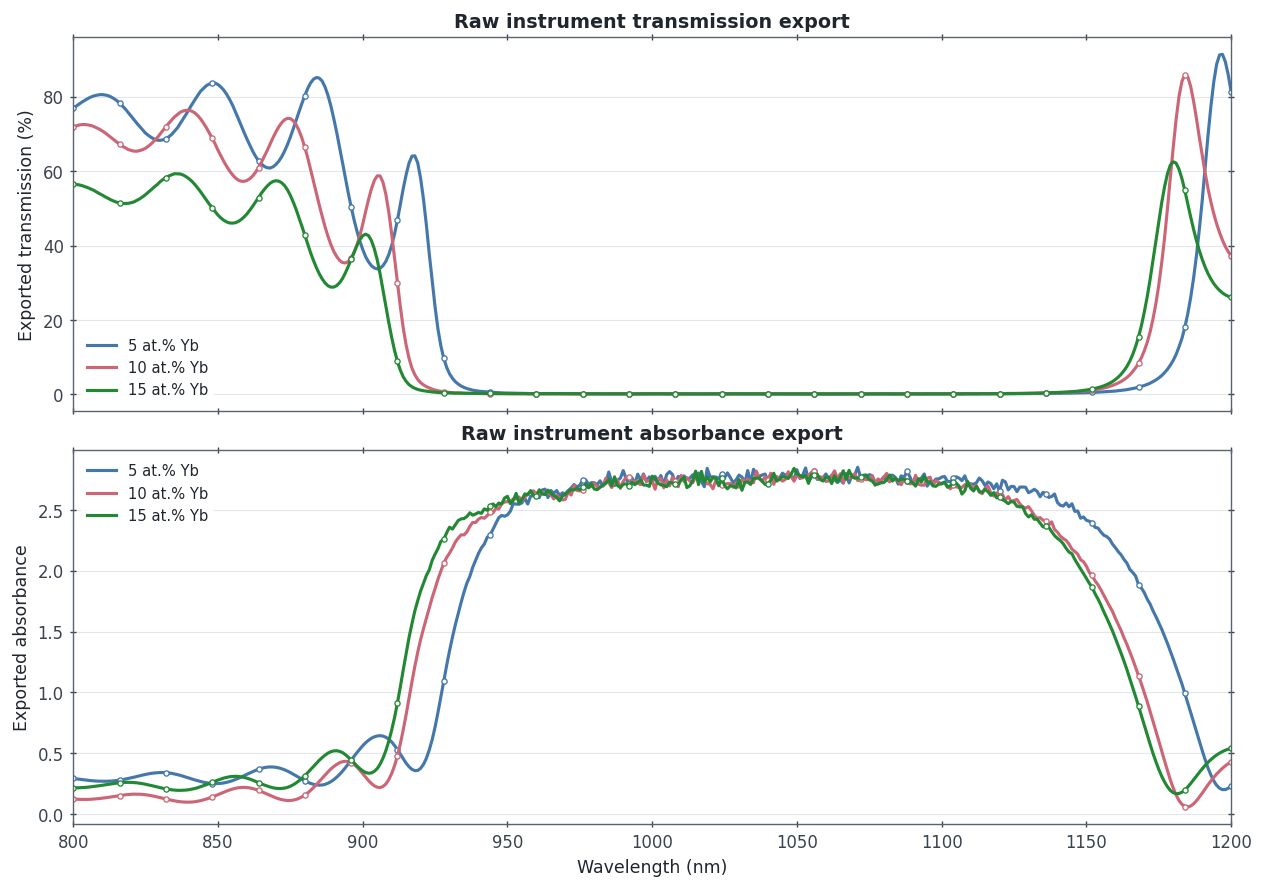

In [2]:
def load_export(path):
    with path.open(newline="", encoding="utf-8-sig") as handle:
        rows = list(csv.reader(handle))
    numeric = []
    for row in rows[2:]:
        if len(row) < 8:
            continue
        try:
            numeric.append([float(value) for value in row[:8]])
        except ValueError:
            continue
    values = np.asarray(numeric)
    return {
        concentration: pd.DataFrame({"wavelength_nm": values[:, 2 * i], "reported": values[:, 2 * i + 1]})
        .sort_values("wavelength_nm")
        for i, concentration in enumerate((None, 5, 10, 15)) if concentration is not None
    }

transmission_export = load_export(HERE / "YbYag_T.csv")
absorbance_export = load_export(HERE / "YbYag_ABS.csv")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for concentration in (5, 10, 15):
    t = transmission_export[concentration]
    a = absorbance_export[concentration]
    axes[0].plot(t.wavelength_nm, t.reported, color=COLORS[concentration], label=f"{concentration} at.% Yb")
    axes[1].plot(a.wavelength_nm, a.reported, color=COLORS[concentration], label=f"{concentration} at.% Yb")
axes[0].set(ylabel="Exported transmission (%)", title="Raw instrument transmission export")
axes[1].set(xlabel="Wavelength (nm)", ylabel="Exported absorbance", title="Raw instrument absorbance export")
axes[0].legend(); axes[1].legend()
axes[1].set_xlim(800, 1200)
save_figure(fig, "01_raw_coated_sample_exports")
plt.show()

## 1a. Uncoated A3: measured transmission

The source repository labels `A3` as a **pure/uncoated sample**. This figure uses only its measured transmittance and corresponding exported absorbance, without correction. Absorbance is derived from the same transmission scan; it is not a second independent measurement. A3's 1060–1100 nm transmittance median is **84.59%**. The user supplied **509 µm thickness**. The user assigns this uncoated specimen nominal 5 at.% Yb; its cross section is therefore calculated conditionally from that nominal concentration.

Source: [updated A3 export](https://github.com/aidasmik/YbYAG/blob/d626e35938bf3ccce9c83d8cf133b6b7aa52a0a3/data/YbYAG_A3_B1_last_spectra.csv).

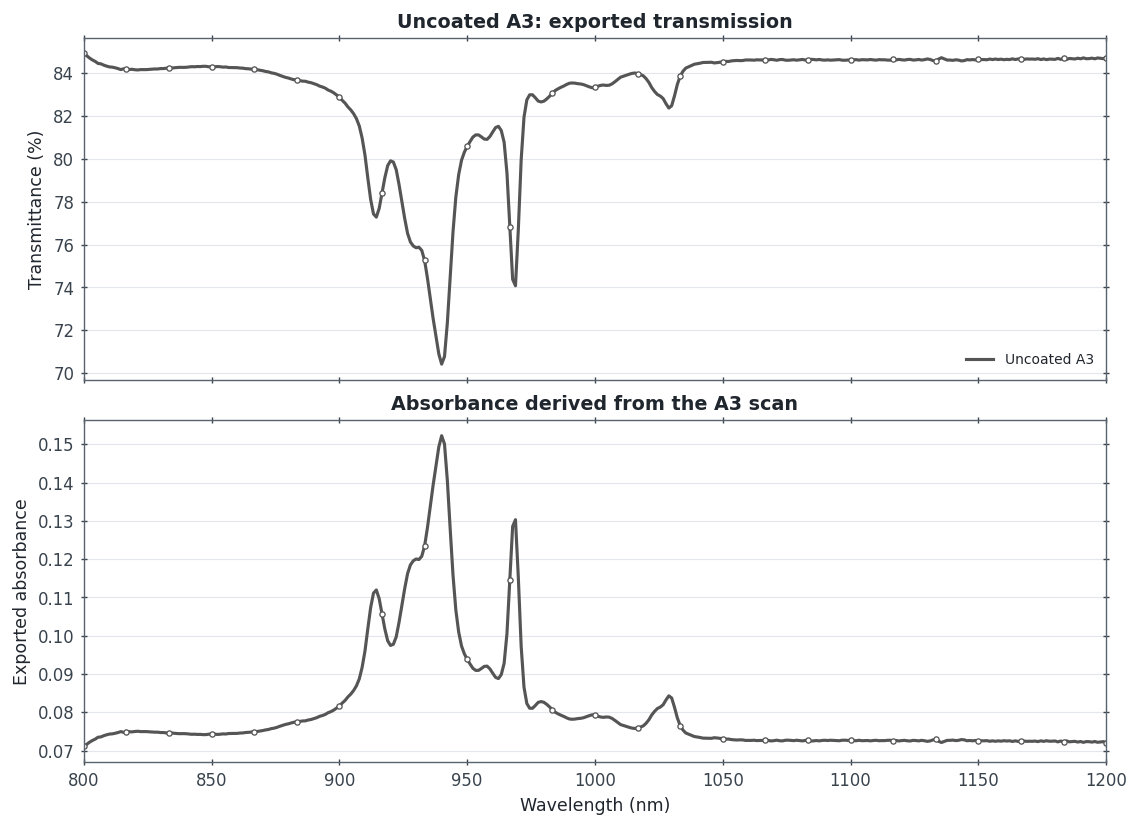

In [3]:
pure_export = pd.read_csv(
    HERE / "YbYAG_A3_B1_last_spectra.csv",
    usecols=["Wavelength (nm)", "A3 Transmittance (%)", "A3 Abs"],
).sort_values("Wavelength (nm)")
pure_wavelength = pure_export["Wavelength (nm)"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(pure_wavelength, pure_export["A3 Transmittance (%)"],
             color="#555555", label="Uncoated A3")
axes[1].plot(pure_wavelength, pure_export["A3 Abs"], color="#555555")
axes[0].set(ylabel="Transmittance (%)", title="Uncoated A3: exported transmission")
axes[1].set(xlabel="Wavelength (nm)", ylabel="Exported absorbance",
            title="Absorbance derived from the A3 scan", xlim=(800, 1200))
axes[0].legend(loc="lower right", fontsize=8)
save_figure(fig, "02_uncoated_A3_transmission")
plt.show()

### A3 one-pass absorption from its 509 µm transmission

Use the same assumed YAG index `n = 1.83`, giving single-face Fresnel reflectance `F`. For an incoherent, plane-parallel uncoated slab with internal single-pass transmission `u = exp(−αd)`, the measured transmission is

$$T=\frac{(1-F)^2u}{1-F^2u^2},\qquad
u=\frac{2T}{(1-F)^2+\sqrt{(1-F)^4+4F^2T^2}},\qquad
\alpha=-\frac{\ln u}{d}. $$

The measured A3 continuum is slightly above the model's lossless-slab transmission. Before inversion, multiply its whole transmission spectrum by the **single constant** `T_lossless / median(T_measured, 1060–1100 nm)`. This assumes negligible Yb absorption in that reference band and corrects a small overall gain offset; it does not fit away absorption features. With user-supplied `d = 0.509 mm = 0.0509 cm`, the result is a **one-pass absorption coefficient** comparable in units with the coated estimates below. Small negative off-band values are retained to show calibration residuals. This model neglects interference, scattering, wavelength dependence of refractive index, and any surface differences. The A3-only [data table](uncoated_A3_measurement.csv) includes the raw and derived values.

In [4]:
a3_thickness_cm = A3_THICKNESS_MM / 10
a3_transmission_raw = pure_export["A3 Transmittance (%)"].to_numpy() / 100
off_band = (pure_wavelength >= 1060) & (pure_wavelength <= 1100)
a3_baseline = float(np.median(a3_transmission_raw[off_band]))
lossless_slab_transmission = (1 - FRESNEL_R) / (1 + FRESNEL_R)
a3_baseline_factor = lossless_slab_transmission / a3_baseline
a3_transmission_adjusted = a3_transmission_raw * a3_baseline_factor

surface_transmission_squared = (1 - FRESNEL_R) ** 2
a3_internal_single_pass = (
    2 * a3_transmission_adjusted
    / (surface_transmission_squared + np.sqrt(
        surface_transmission_squared ** 2
        + 4 * FRESNEL_R ** 2 * a3_transmission_adjusted ** 2))
)
a3_alpha_cm_inverse = -np.log(a3_internal_single_pass) / a3_thickness_cm
a3_absorbance_one_pass = -np.log10(a3_internal_single_pass)
reconstructed_transmission = (
    surface_transmission_squared * a3_internal_single_pass
    / (1 - FRESNEL_R ** 2 * a3_internal_single_pass ** 2)
)
assert np.max(np.abs(reconstructed_transmission - a3_transmission_adjusted)) < 1e-12

a3_results = pd.DataFrame({
    "wavelength_nm": pure_wavelength,
    "user_supplied_thickness_mm": A3_THICKNESS_MM,
    "assumed_refractive_index": YAG_INDEX,
    "measured_continuum_1060_1100": a3_baseline,
    "baseline_multiplier": a3_baseline_factor,
    "transmittance_percent": pure_export["A3 Transmittance (%)"].to_numpy(),
    "exported_absorbance": pure_export["A3 Abs"].to_numpy(),
    "baseline_adjusted_transmittance": a3_transmission_adjusted,
    "internal_single_pass_transmission": a3_internal_single_pass,
    "one_pass_absorbance": a3_absorbance_one_pass,
    "absorption_coefficient_cm_inverse": a3_alpha_cm_inverse,
})
a3_results.to_csv(HERE / "uncoated_A3_measurement.csv", index=False)
print(f"A3: d={A3_THICKNESS_MM:g} mm, Fresnel R={FRESNEL_R:.5f}, "
      f"lossless T={lossless_slab_transmission:.5f}, "
      f"measured continuum={a3_baseline:.5f}, "
      f"baseline multiplier={a3_baseline_factor:.6f}")
for wavelength in (941, 969, 1030):
    index = int(np.argmin(np.abs(pure_wavelength - wavelength)))
    print(f"A3 near {wavelength} nm ({pure_wavelength[index]:.2f} nm): "
          f"alpha={a3_alpha_cm_inverse[index]:.3f} cm^-1")

A3: d=0.509 mm, Fresnel R=0.08602, lossless T=0.84159, measured continuum=0.84593, baseline multiplier=0.994871
A3 near 941 nm (941.14 nm): alpha=3.459 cm^-1
A3 near 969 nm (968.91 nm): alpha=2.574 cm^-1
A3 near 1030 nm (1030.02 nm): alpha=0.495 cm^-1


## 2. Reflection measurements only: both sides of each coated sample

The text files store decimal commas split by the CSV delimiter, so `800,00000,23,80109` means **800.00000 nm, 23.80109%**. Solid lines are the open entrance face; dashed lines are the high-reflection coated face. Values above 100% are retained as recorded because they reveal a reference/calibration problem.

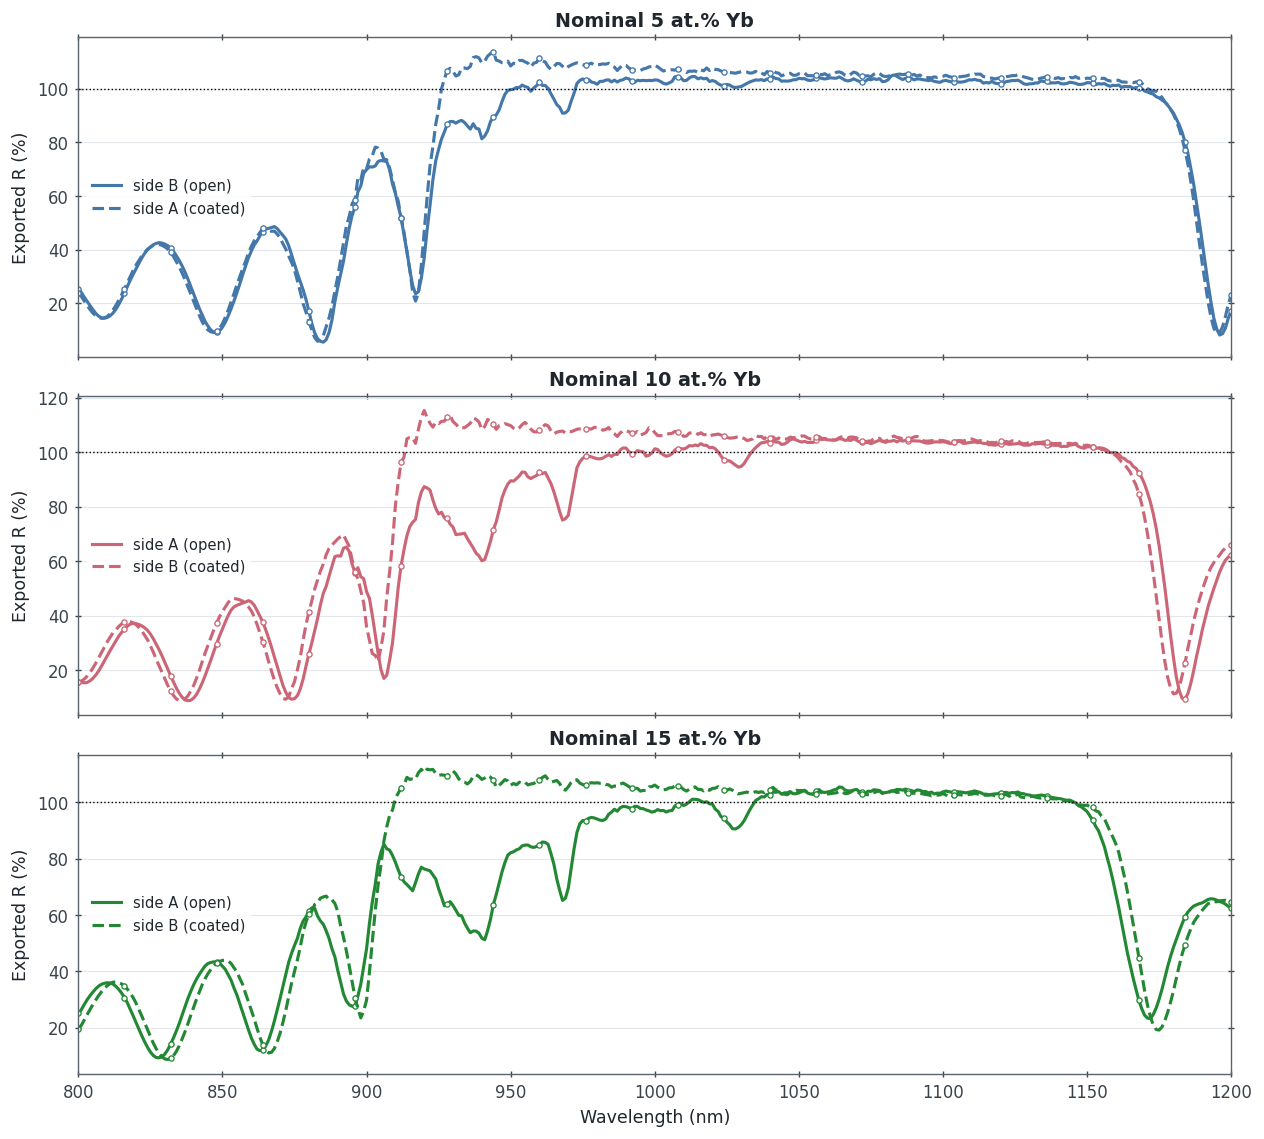

In [5]:
def load_reflection(concentration, side):
    path = HERE / "reflection" / f"YbYag_{concentration}_{side}_R.txt"
    parsed = []
    for line in path.read_text(encoding="ascii").splitlines()[2:]:
        fields = line.split(",")
        if len(fields) == 4:
            parsed.append((float(fields[0] + "." + fields[1]),
                           float(fields[2] + "." + fields[3])))
    return pd.DataFrame(parsed, columns=["wavelength_nm", "R_exported_percent"])

reflection_raw = {}
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)
for axis, concentration in zip(axes, (5, 10, 15)):
    open_side, coated_side = OPEN_AND_COATED_SIDES[concentration]
    for side, style, label in ((open_side, "-", "open"), (coated_side, "--", "coated")):
        frame = load_reflection(concentration, side)
        reflection_raw[(concentration, side)] = frame
        axis.plot(frame.wavelength_nm, frame.R_exported_percent, style,
                  color=COLORS[concentration], label=f"side {side} ({label})")
    axis.axhline(100, color="black", linestyle=":", linewidth=0.8)
    axis.set(ylabel="Exported R (%)", title=f"Nominal {concentration} at.% Yb")
    axis.legend()
axes[-1].set(xlabel="Wavelength (nm)", xlim=(800, 1200))
save_figure(fig, "03_raw_paired_reflection")
plt.show()

## 3. Apply an aluminum-mirror reference curve

If the spectrometer treated an aluminum reference mirror as 100%, the first estimate is `R_Al-only = R_exported × R_Al(λ)`. The included curve is from a [NIST first-surface aluminum mirror example](https://nvlpubs.nist.gov/nistpubs/Legacy/SP/nistspecialpublication250-48.pdf) at 6° incidence. It **does not identify or calibrate the mirror used for these samples**. Interpolation supplies the 1-nm values. Some Al-only coated-face readings remain above 1. We therefore calculate the **smallest common gain divisor** `g = max(1, max R_Al-only,coated)` across all three samples and wavelengths and use `R_bounded = R_Al-only/g` in the later absorption model. The same `g` is applied to both faces of every sample. This enforces passivity without clipping or changing the relative shape within a scan, but it is an inferred instrument-gain correction, **not an absolute calibration**.

The plot below shows **all six corrected A/B spectra over 800–1200 nm** after the aluminum-reference and common-gain correction. The next section fits a single additional smooth response curve to the reflecting sections and applies it unchanged to every concentration and face. Raw, Al-only, and bounded values remain separately available.

Common residual gain divisor (minimal passivity bound): 1.060494185


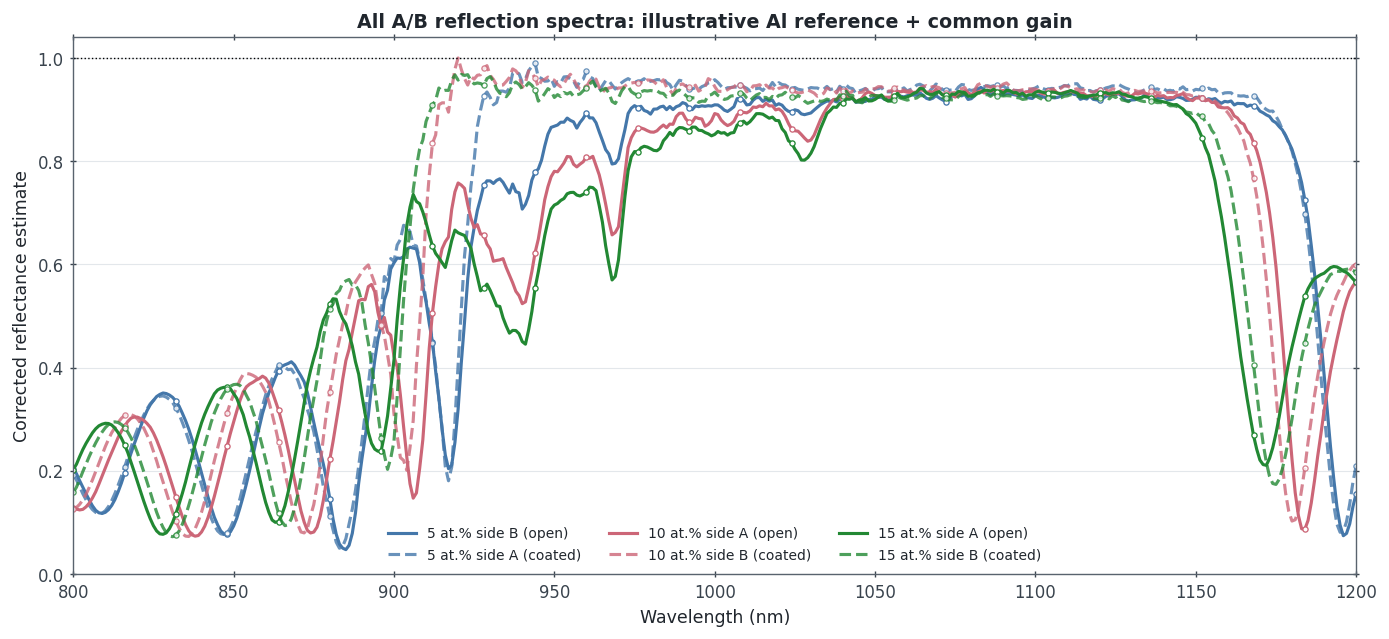

In [6]:
mirror = pd.read_csv(MIRROR_CSV).sort_values("wavelength_nm")
aluminum_only_coated_peaks = []
for concentration, (_, coated_side) in OPEN_AND_COATED_SIDES.items():
    coated_scan = reflection_raw[(concentration, coated_side)]
    reference = np.interp(coated_scan.wavelength_nm, mirror.wavelength_nm,
                          mirror.reflectance_fraction)
    aluminum_only_coated_peaks.append(float((coated_scan.R_exported_percent / 100 * reference).max()))
COMMON_GAIN_DIVISOR = max(1.0, *aluminum_only_coated_peaks)
print(f"Common residual gain divisor (minimal passivity bound): {COMMON_GAIN_DIVISOR:.9f}")

corrected = {}
for concentration, (open_side, coated_side) in OPEN_AND_COATED_SIDES.items():
    open_frame = reflection_raw[(concentration, open_side)].copy()
    coated_frame = reflection_raw[(concentration, coated_side)].copy()
    frame = open_frame.merge(coated_frame, on="wavelength_nm", suffixes=("_open", "_coated"))
    frame["R_aluminum"] = np.interp(frame.wavelength_nm, mirror.wavelength_nm,
                                     mirror.reflectance_fraction)
    frame["R_open_aluminum_only"] = frame.R_exported_percent_open / 100 * frame.R_aluminum
    frame["R_coated_aluminum_only"] = frame.R_exported_percent_coated / 100 * frame.R_aluminum
    frame["R_open"] = frame.R_open_aluminum_only / COMMON_GAIN_DIVISOR
    frame["R_coated"] = frame.R_coated_aluminum_only / COMMON_GAIN_DIVISOR
    corrected[concentration] = frame

fig, axis = plt.subplots(figsize=(11, 5), constrained_layout=True)
for concentration, frame in corrected.items():
    open_side, coated_side = OPEN_AND_COATED_SIDES[concentration]
    axis.plot(frame.wavelength_nm, frame.R_open, color=COLORS[concentration],
              label=f"{concentration} at.% side {open_side} (open)")
    axis.plot(frame.wavelength_nm, frame.R_coated, "--", color=COLORS[concentration],
              alpha=0.8, label=f"{concentration} at.% side {coated_side} (coated)")
axis.axhline(1, color="black", linestyle=":", linewidth=0.8)
axis.set(xlabel="Wavelength (nm)", ylabel="Corrected reflectance estimate",
         title="All A/B reflection spectra: illustrative Al reference + common gain",
         xlim=(800, 1200), ylim=(0, 1.04))
axis.legend(ncol=3, fontsize=8)
save_figure(fig, "04_aluminum_and_gain_corrected_reflection")
plt.show()

### 3a. One smooth empirical compensation curve for every sample

Over **950–1100 nm**, normalize each coated scan by its median in the fitting windows, pool all three normalized scans, and fit **one robust cubic continuum**. The fit excludes **962–975 nm** and **1021–1038 nm**, where narrow Yb-related structure could bias the baseline. One common scale then keeps all six corrected faces at or below 0.999. **Exactly the same wavelength-dependent multiplier** is applied to 5%, 10%, and 15%, on both A and B. This removes the shared broad baseline bend while leaving concentration-dependent offsets and narrower structure visible. The 151-point curve is in `common_hr_compensation_curve_950_1100.csv`; all before/after values are in `smooth_hr_compensation_950_1100.csv`.

This is **not the true aluminum-mirror reflectance curve**. The [NIST example](https://nvlpubs.nist.gov/nistpubs/Legacy/SP/nistspecialpublication250-48.pdf) characterizes a different mirror, and these sample scans alone cannot separate instrument response from the coating's own spectral shape. The smooth correction is therefore a relative visualization and is **not used in the absorption or cross-section calculations below**. A measured reference mirror under the same geometry is needed for an absolute correction.

5 at.%: coated early-minus-late median +0.0041 before, +0.0008 after; largest corrected face 0.9990
10 at.%: coated early-minus-late median +0.0042 before, -0.0006 after; largest corrected face 0.9923
15 at.%: coated early-minus-late median +0.0021 before, -0.0023 after; largest corrected face 0.9800


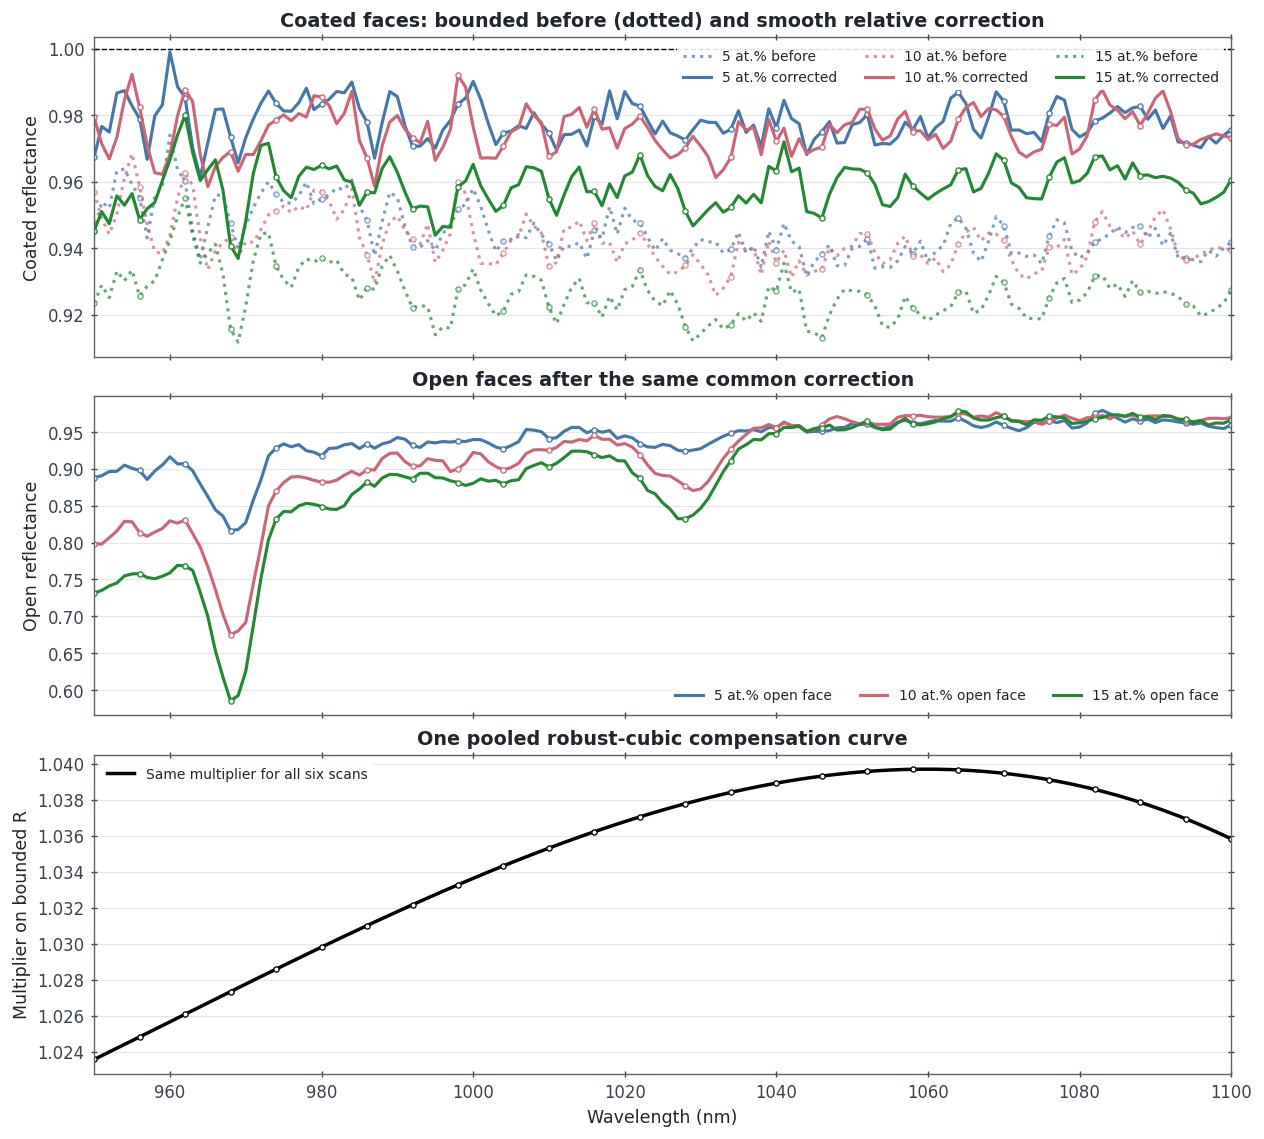

In [7]:
from scipy.optimize import least_squares

fit_bands = {
    concentration: frame.query("950 <= wavelength_nm <= 1100").copy()
    for concentration, frame in corrected.items()
}
fit_wavelengths = fit_bands[5].wavelength_nm.to_numpy()
scaled_wavelength = (fit_wavelengths - 1025) / 75
fit_mask = ~((fit_wavelengths >= 962) & (fit_wavelengths <= 975) |
             (fit_wavelengths >= 1021) & (fit_wavelengths <= 1038))
pooled_coated = []
for band in fit_bands.values():
    assert np.array_equal(band.wavelength_nm.to_numpy(), fit_wavelengths)
    coated_values = band.R_coated.to_numpy()
    pooled_coated.append(coated_values[fit_mask] / np.median(coated_values[fit_mask]))
fit_x = np.tile(scaled_wavelength[fit_mask], len(fit_bands))
fit_y = np.concatenate(pooled_coated)
initial_coefficients = np.polynomial.polynomial.polyfit(fit_x, fit_y, deg=3)
fit = least_squares(
    lambda coefficients: np.polynomial.polynomial.polyval(fit_x, coefficients) - fit_y,
    initial_coefficients, loss="soft_l1", f_scale=0.005)
common_shape = np.polynomial.polynomial.polyval(scaled_wavelength, fit.x)
assert np.all(common_shape > 0)
maximum_shape_corrected_face = max(
    float((band[["R_open", "R_coated"]].max(axis=1).to_numpy() / common_shape).max())
    for band in fit_bands.values())
common_scale = 0.999 / maximum_shape_corrected_face
common_multiplier = common_scale / common_shape
pd.DataFrame({
    "wavelength_nm": fit_wavelengths,
    "pooled_coated_continuum_shape": common_shape,
    "common_compensation_multiplier": common_multiplier,
}).to_csv(HERE / "common_hr_compensation_curve_950_1100.csv", index=False)

smooth_compensated = {}
compensation_rows = []
for concentration, band in fit_bands.items():
    band["common_shape"] = common_shape
    band["smooth_compensation_multiplier"] = common_multiplier
    band["R_open_smooth"] = band.R_open * band.smooth_compensation_multiplier
    band["R_coated_smooth"] = band.R_coated * band.smooth_compensation_multiplier
    smooth_compensated[concentration] = band

    early = band.query("980 <= wavelength_nm <= 1015")
    late = band.query("1060 <= wavelength_nm <= 1100")
    before_bend = float(early.R_coated.median() - late.R_coated.median())
    after_bend = float(early.R_coated_smooth.median() - late.R_coated_smooth.median())
    print(f"{concentration} at.%: coated early-minus-late median "
          f"{before_bend:+.4f} before, {after_bend:+.4f} after; "
          f"largest corrected face {max(band.R_open_smooth.max(), band.R_coated_smooth.max()):.4f}")
    compensation_rows.append(pd.DataFrame({
        "nominal_yb_at_percent": concentration,
        "wavelength_nm": band.wavelength_nm,
        "open_side": OPEN_AND_COATED_SIDES[concentration][0],
        "coated_side": OPEN_AND_COATED_SIDES[concentration][1],
        "bounded_open_reflectance": band.R_open,
        "bounded_coated_reflectance": band.R_coated,
        "common_shape": band.common_shape,
        "smooth_compensation_multiplier": band.smooth_compensation_multiplier,
        "smooth_corrected_open_reflectance": band.R_open_smooth,
        "smooth_corrected_coated_reflectance": band.R_coated_smooth,
    }))

compensation_table = pd.concat(compensation_rows, ignore_index=True)
compensation_table.to_csv(HERE / "smooth_hr_compensation_950_1100.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)
for concentration, band in smooth_compensated.items():
    color = COLORS[concentration]
    axes[0].plot(band.wavelength_nm, band.R_coated, ":", color=color,
                 alpha=0.7, label=f"{concentration} at.% before")
    axes[0].plot(band.wavelength_nm, band.R_coated_smooth, color=color,
                 label=f"{concentration} at.% corrected")
    axes[1].plot(band.wavelength_nm, band.R_open_smooth, color=color,
                 label=f"{concentration} at.% open face")
axes[2].plot(fit_wavelengths, common_multiplier, color="black", linewidth=2,
             label="Same multiplier for all six scans")
axes[0].axhline(1, color="black", linestyle="--", linewidth=0.8)
axes[0].set(ylabel="Coated reflectance", title="Coated faces: bounded before (dotted) and smooth relative correction")
axes[1].set(ylabel="Open reflectance", title="Open faces after the same common correction")
axes[2].set(xlabel="Wavelength (nm)", ylabel="Multiplier on bounded R",
            title="One pooled robust-cubic compensation curve", xlim=(950, 1100))
for axis in axes:
    axis.legend(ncol=3, fontsize=8)
save_figure(fig, "05_shared_high_reflection_compensation")
plt.show()

### 3b. Apply the shared curve to the full 800–1200 nm reflection scans

The shared curve was fitted only on **950–1100 nm**. To show the wider scans without extrapolating its cubic into coating-edge regions, hold its end values and blend the multiplier smoothly from **1 at 940 nm** to the fitted value at 950 nm, and from the fitted value at 1100 nm back to **1 at 1125 nm**. The multiplier is 1 outside 940–1125 nm. It is **identical for all six A/B spectra at every wavelength**. The transition positions keep the full-range estimates at or below 1; they are display choices, not mirror-calibration data. The resulting curve and six full spectra are exported separately. The absorption calculation below continues to use the earlier bounded data.

5 at.%: corrected max 0.9990
10 at.%: corrected max 1.0000
15 at.%: corrected max 0.9800


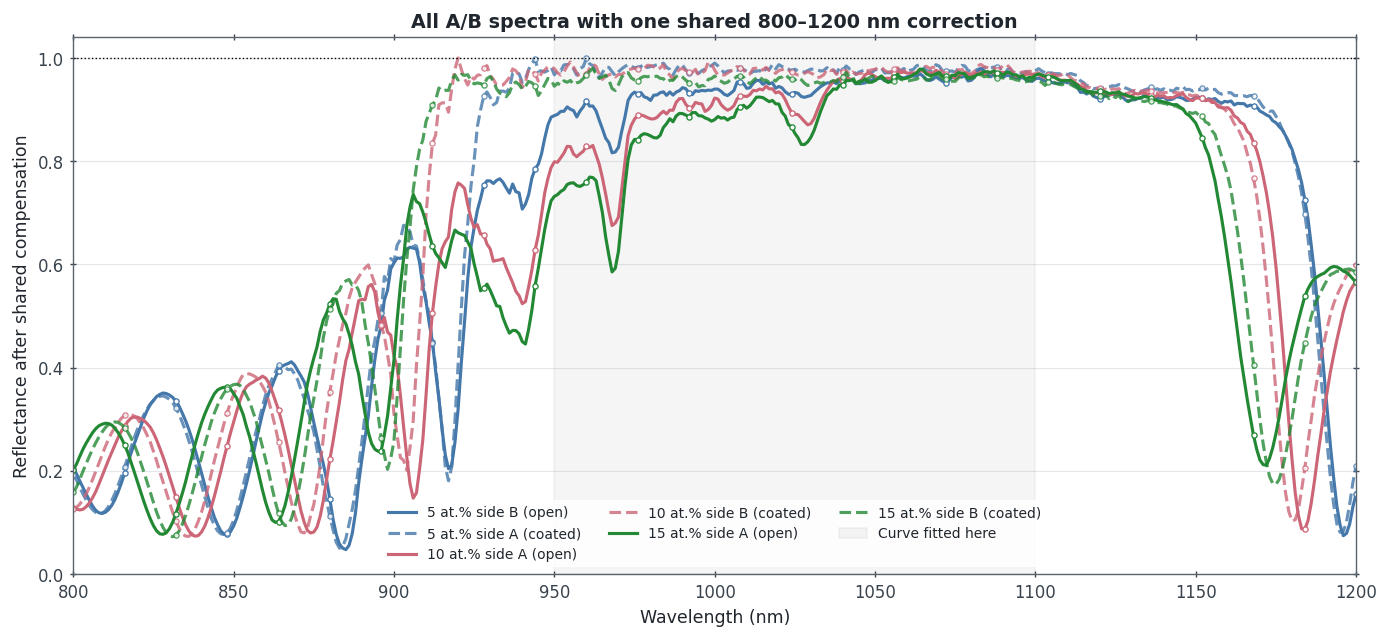

In [8]:
full_wavelengths = corrected[5].wavelength_nm.to_numpy()
held_fit_multiplier = np.interp(full_wavelengths, fit_wavelengths, common_multiplier)

def smooth_step(values):
    fraction = np.clip(values, 0, 1)
    return fraction * fraction * (3 - 2 * fraction)

blend = np.ones_like(full_wavelengths, dtype=float)
left = full_wavelengths < 950
right = full_wavelengths > 1100
blend[left] = smooth_step((full_wavelengths[left] - 940) / 10)
blend[right] = 1 - smooth_step((full_wavelengths[right] - 1100) / 25)
full_multiplier = 1 + blend * (held_fit_multiplier - 1)

pd.DataFrame({
    "wavelength_nm": full_wavelengths,
    "common_compensation_multiplier": full_multiplier,
    "region": np.where((full_wavelengths >= 950) & (full_wavelengths <= 1100), "fitted",
                np.where((full_wavelengths > 940) & (full_wavelengths < 1125),
                         "smooth_transition", "unchanged")),
}).to_csv(HERE / "common_reflection_compensation_800_1200.csv", index=False)

wide_rows = []
fig, axis = plt.subplots(figsize=(11, 5), constrained_layout=True)
for concentration, frame in corrected.items():
    assert np.array_equal(frame.wavelength_nm.to_numpy(), full_wavelengths)
    open_side, coated_side = OPEN_AND_COATED_SIDES[concentration]
    open_corrected = frame.R_open.to_numpy() * full_multiplier
    coated_corrected = frame.R_coated.to_numpy() * full_multiplier
    assert max(open_corrected.max(), coated_corrected.max()) <= 1 + 1e-12
    axis.plot(full_wavelengths, open_corrected, color=COLORS[concentration],
              label=f"{concentration} at.% side {open_side} (open)")
    axis.plot(full_wavelengths, coated_corrected, "--", color=COLORS[concentration],
              alpha=0.8, label=f"{concentration} at.% side {coated_side} (coated)")
    wide_rows.append(pd.DataFrame({
        "nominal_yb_at_percent": concentration,
        "wavelength_nm": full_wavelengths,
        "open_side": open_side,
        "coated_side": coated_side,
        "common_compensation_multiplier": full_multiplier,
        "bounded_open_reflectance": frame.R_open,
        "bounded_coated_reflectance": frame.R_coated,
        "wide_corrected_open_reflectance": open_corrected,
        "wide_corrected_coated_reflectance": coated_corrected,
    }))
    print(f"{concentration} at.%: corrected max "
          f"{max(open_corrected.max(), coated_corrected.max()):.4f}")

wide_corrected = pd.concat(wide_rows, ignore_index=True)
wide_corrected.to_csv(HERE / "wide_reflection_corrected_800_1200.csv", index=False)
axis.axvspan(950, 1100, color="gray", alpha=0.08, label="Curve fitted here")
axis.axhline(1, color="black", linestyle=":", linewidth=0.8)
axis.set(xlabel="Wavelength (nm)", ylabel="Reflectance after shared compensation",
         title="All A/B spectra with one shared 800–1200 nm correction",
         xlim=(800, 1200), ylim=(0, 1.04))
axis.legend(ncol=3, fontsize=8)
save_figure(fig, "06_full_range_shared_corrected_reflection")
plt.show()

## 4. Infer the internal two-pass attenuation

For front-face Fresnel reflectance `F`, the incoherent reflected signal obeys

$$R_{\rm open}=F+\frac{(1-F)^2 y}{1-Fy},\qquad
y=R_{\rm back}e^{-2\alpha d}=\frac{R_{\rm open}-F}{(1-F)^2+F(R_{\rm open}-F)}.$$

We use the coated-face scan for the **wavelength shape** of `R_back`, and determine one constant per sample from the median of `y/R_coated` over **1060–1100 nm**. That assumes negligible Yb absorption there. `T₂ = (y/R_coated)/median(y/R_coated)` is the model's inferred internal two-pass transmission. The unnormalized ratio is also retained; its off-band value need not be 1. Nonpositive ratios are flagged as invalid instead of logged.

5 at.%: continuum factor=0.98331; invalid wavelengths=12
10 at.%: continuum factor=0.99222; invalid wavelengths=8
15 at.%: continuum factor=1.00722; invalid wavelengths=4


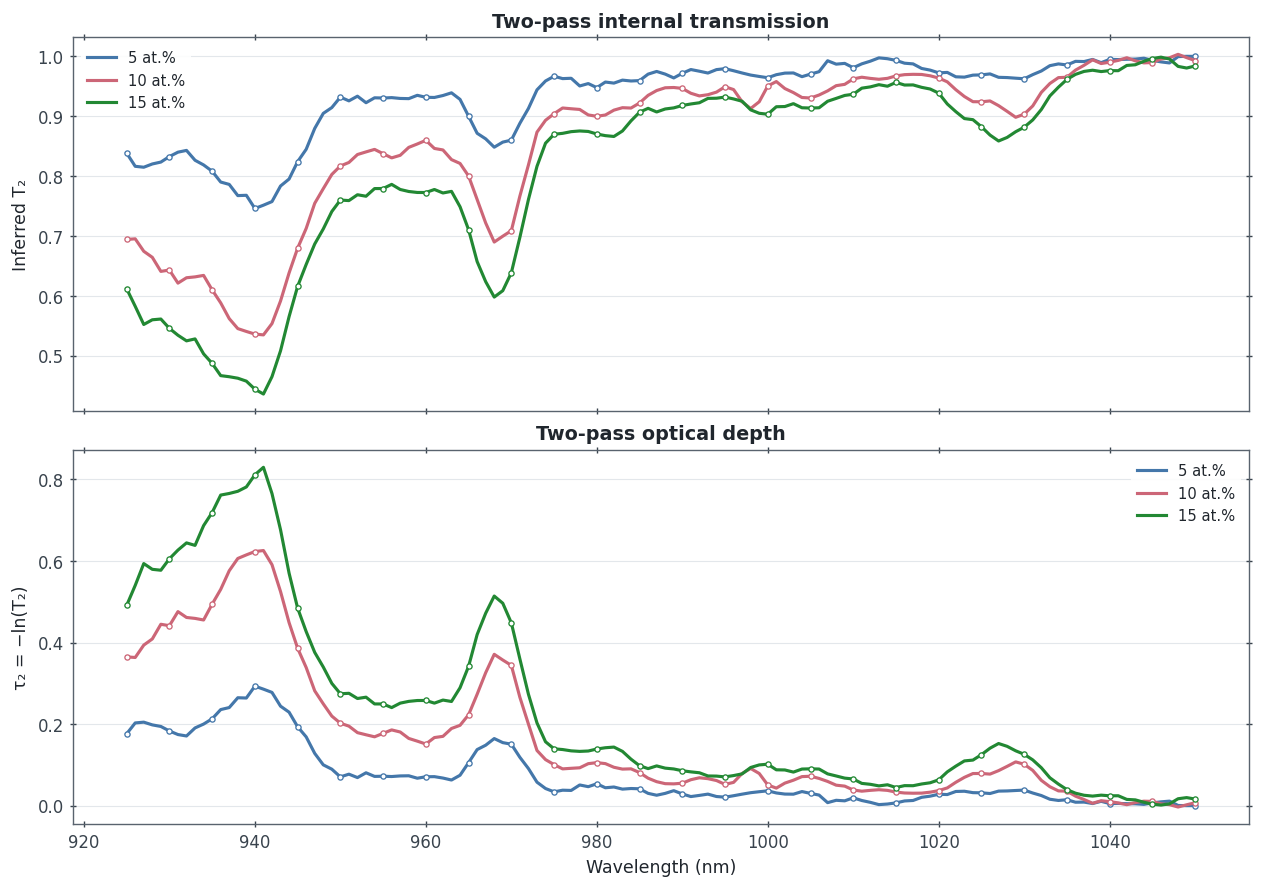

In [9]:
spectra = {}
for concentration, frame in corrected.items():
    frame = frame.copy()
    frame["internal_return_product"] = (
        (frame.R_open - FRESNEL_R)
        / ((1 - FRESNEL_R) ** 2 + FRESNEL_R * (frame.R_open - FRESNEL_R))
    )
    frame["unnormalized_return_ratio"] = frame.internal_return_product / frame.R_coated
    continuum = frame.query("1060 <= wavelength_nm <= 1100")
    scale = float(continuum.unnormalized_return_ratio.median())
    frame["T_two_pass"] = frame.unnormalized_return_ratio / scale
    frame["model_valid"] = frame.T_two_pass > 0
    frame["tau_two_pass"] = -np.log(frame.T_two_pass.where(frame.model_valid))
    spectra[concentration] = frame
    print(f"{concentration} at.%: continuum factor={scale:.5f}; "
          f"invalid wavelengths={int((~frame.model_valid).sum())}")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    axes[0].plot(subset.wavelength_nm, subset.T_two_pass, color=COLORS[concentration],
                 label=f"{concentration} at.%")
    axes[1].plot(subset.wavelength_nm, subset.tau_two_pass, color=COLORS[concentration],
                 label=f"{concentration} at.%")
axes[0].set(ylabel="Inferred T₂", title="Two-pass internal transmission")
axes[1].set(xlabel="Wavelength (nm)", ylabel="τ₂ = −ln(T₂)",
            title="Two-pass optical depth")
axes[0].legend(); axes[1].legend()
save_figure(fig, "07_two_pass_attenuation")
plt.show()

## 5. Divide by two; calculate one-pass absorbance

The reflected path crosses each coated active layer twice, so `τ₁ = τ₂/2`. The base-10 **one-pass absorbance** is `A₁ = τ₁/ln(10) = −log₁₀(T₂)/2`. The first plot explicitly shows the division by two. The second plots the coated one-pass absorbances alongside **A3's single-pass absorbance from its 509 µm transmission**. Absorbance depends on each specimen's thickness; the following absorption-coefficient plot divides out that thickness. Small negative values are retained as calibration diagnostics.

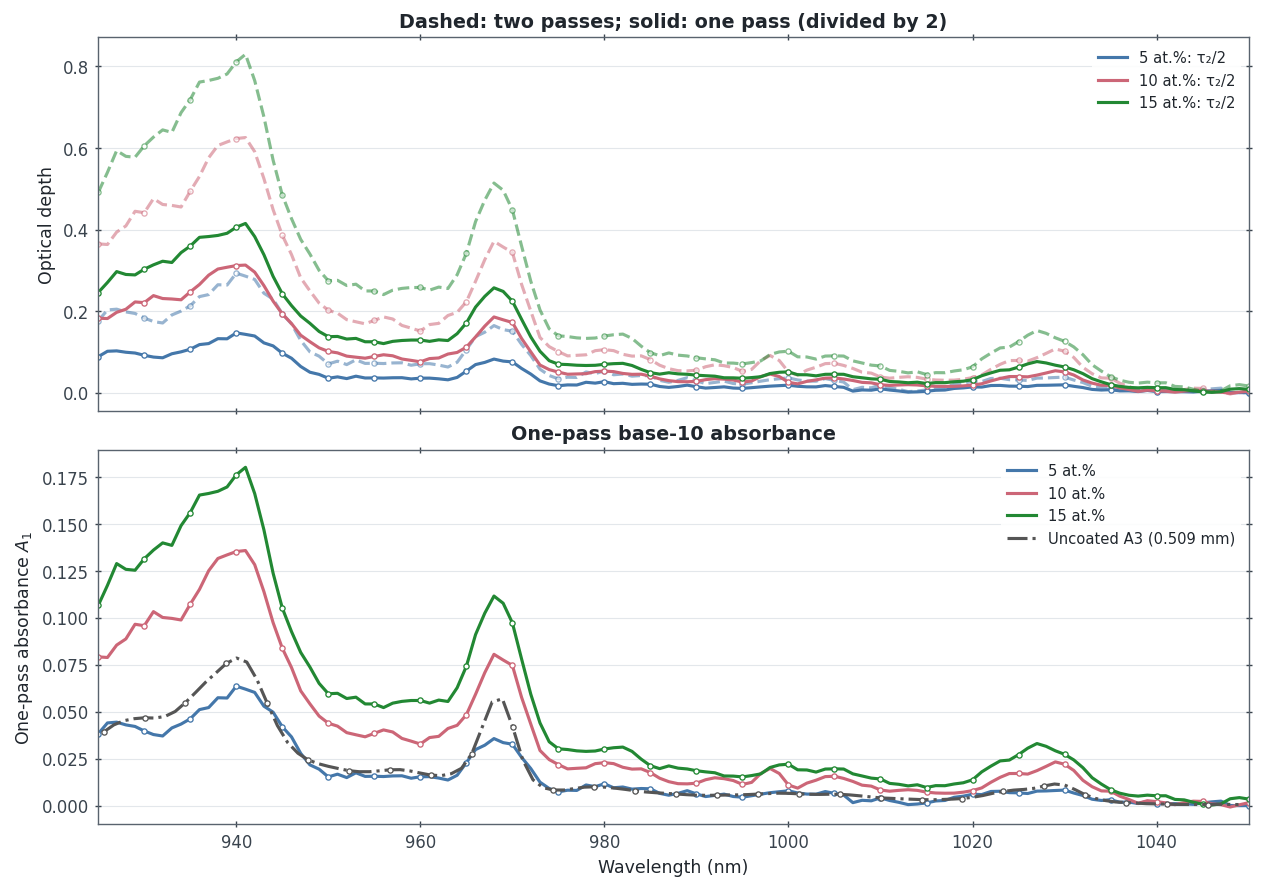

In [10]:
for concentration, frame in spectra.items():
    frame["tau_one_pass"] = frame.tau_two_pass / 2
    frame["absorbance_one_pass"] = frame.tau_one_pass / np.log(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    axes[0].plot(subset.wavelength_nm, subset.tau_two_pass, "--",
                 color=COLORS[concentration], alpha=0.55)
    axes[0].plot(subset.wavelength_nm, subset.tau_one_pass,
                 color=COLORS[concentration], label=f"{concentration} at.%: τ₂/2")
    axes[1].plot(subset.wavelength_nm, subset.absorbance_one_pass,
                 color=COLORS[concentration], label=f"{concentration} at.%")
a3_absorbance_window = (pure_wavelength >= 925) & (pure_wavelength <= 1050)
axes[1].plot(pure_wavelength[a3_absorbance_window],
             a3_absorbance_one_pass[a3_absorbance_window], color="#555555",
             linestyle="-.", label=f"Uncoated A3 ({A3_THICKNESS_MM:g} mm)")
axes[0].set(ylabel="Optical depth", title="Dashed: two passes; solid: one pass (divided by 2)")
axes[1].set(xlabel="Wavelength (nm)", ylabel="One-pass absorbance $A_1$",
            title="One-pass base-10 absorbance", xlim=(925, 1050))
axes[0].legend(); axes[1].legend()
save_figure(fig, "08_one_pass_absorbance")
plt.show()

## 6. Convert one-pass absorbance to absorption cross section

With active-layer thickness `d` in cm and ion density `N_Yb = 1.385×10²⁰ × C` cm⁻³ for nominal at.% `C`,

$$\alpha(\lambda)=\frac{\tau_1(\lambda)}{d},\qquad
\sigma_a(\lambda)=\frac{\alpha(\lambda)}{N_{\rm Yb}}.$$

The density conversion is recorded in the [source repository's literature table](https://github.com/aidasmik/YbYAG/blob/d626e35938bf3ccce9c83d8cf133b6b7aa52a0a3/data/analysis_2026_09_17/literature_reference_values.csv). The coated thicknesses supplied for this calculation are **502 µm (5 at.%), 463 µm (10 at.%), and 472 µm (15 at.%)**. Cross section scales inversely with the assigned thickness. A3's **509 µm thickness** allows its absorption coefficient to be plotted with the coated samples in the second figure. That figure also normalizes each curve by its value near 941 nm to compare spectral shapes; this shape normalization is for display only. A3 is included in the cross-section figure using the user-supplied nominal 5 at.% concentration; this is not an independent composition assay.

In [11]:
# Edit these active-layer thicknesses (µm) when measured values are available.
THICKNESS_UM = {5: 502.0, 10: 463.0, 15: 472.0}

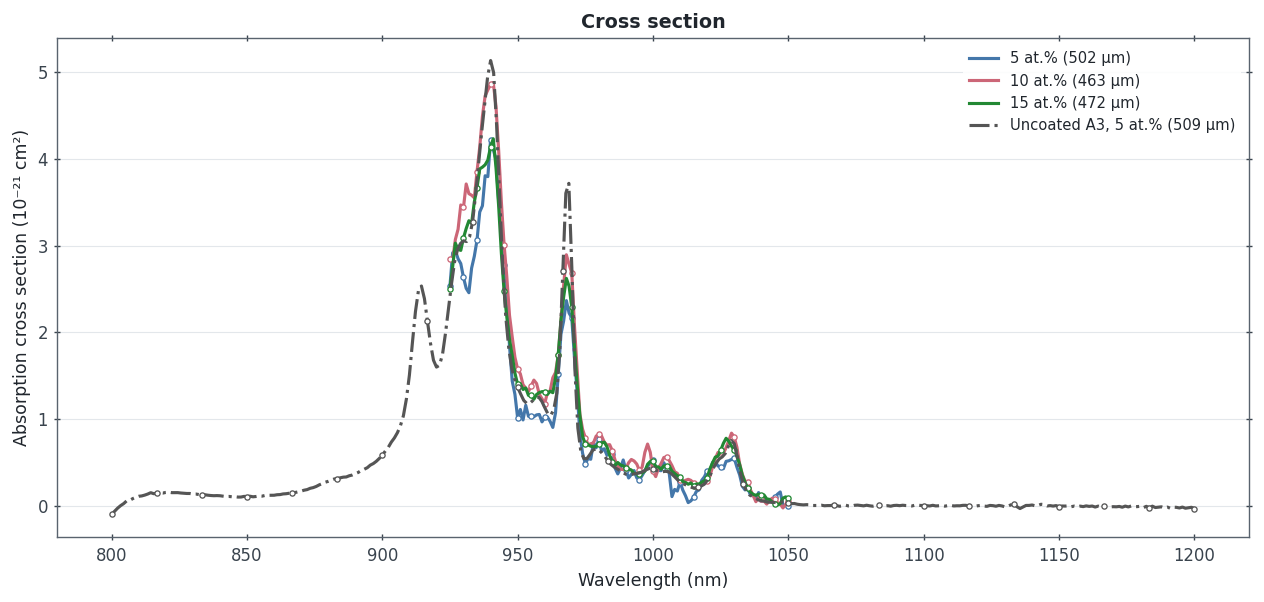

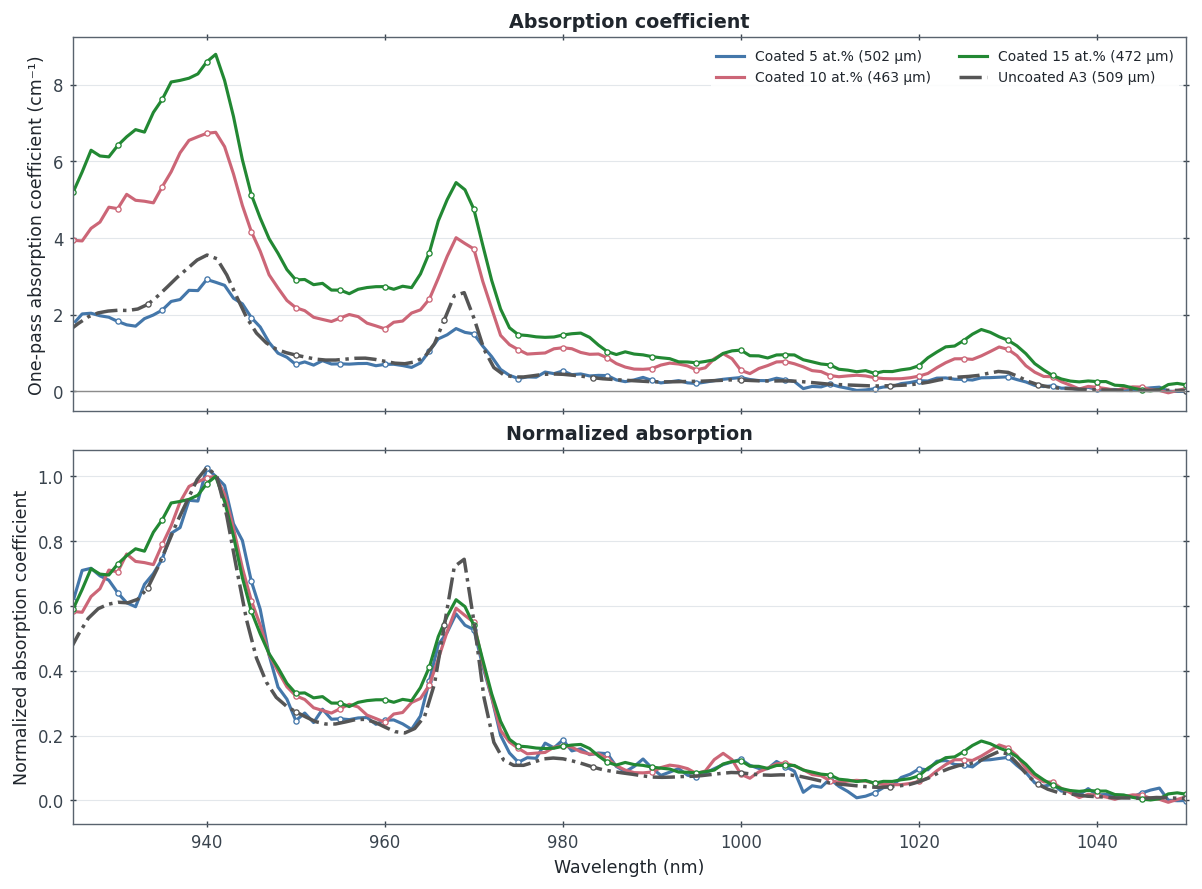

In [12]:
for concentration, frame in spectra.items():
    thickness_cm = THICKNESS_UM[concentration] * 1e-4
    ion_density = YB_ION_DENSITY_PER_AT_PERCENT * concentration
    frame["alpha_one_pass_cm_inverse"] = frame.tau_one_pass / thickness_cm
    frame["sigma_abs_cm2"] = frame.alpha_one_pass_cm_inverse / ion_density

a3_sigma_abs_cm2 = a3_alpha_cm_inverse / (YB_ION_DENSITY_PER_AT_PERCENT * A3_NOMINAL_YB_AT_PERCENT)

fig, axis = plt.subplots(figsize=(10, 4.7), constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    axis.plot(subset.wavelength_nm, subset.sigma_abs_cm2 / 1e-21,
              color=COLORS[concentration], label=f"{concentration} at.% ({THICKNESS_UM[concentration]:g} µm)")
axis.plot(pure_wavelength, a3_sigma_abs_cm2 / 1e-21, color="#555555", linestyle="-.", label=f"Uncoated A3, {A3_NOMINAL_YB_AT_PERCENT:g} at.% ({A3_THICKNESS_MM * 1000:g} µm)")
axis.set(xlabel="Wavelength (nm)", ylabel="Absorption cross section (10⁻²¹ cm²)",
         title="Cross section")
axis.legend()
save_figure(fig, "09_conditional_absorption_cross_section")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True, constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    alpha_941 = float(frame.loc[frame.wavelength_nm == 941,
                                "alpha_one_pass_cm_inverse"].iloc[0])
    axes[0].plot(subset.wavelength_nm, subset.alpha_one_pass_cm_inverse,
                 color=COLORS[concentration],
                 label=f"Coated {concentration} at.% ({THICKNESS_UM[concentration]:g} µm)")
    axes[1].plot(subset.wavelength_nm, subset.alpha_one_pass_cm_inverse / alpha_941,
                 color=COLORS[concentration])
a3_941_index = int(np.argmin(np.abs(pure_wavelength - 941)))
axes[0].plot(pure_wavelength, a3_alpha_cm_inverse, color="#555555",
             linewidth=2, linestyle="-.", label=f"Uncoated A3 ({A3_THICKNESS_MM * 1000:g} µm)")
axes[1].plot(pure_wavelength, a3_alpha_cm_inverse / a3_alpha_cm_inverse[a3_941_index],
             color="#555555", linewidth=2, linestyle="-.")
axes[0].axhline(0, color="0.55", linewidth=0.8)
axes[0].set(ylabel="One-pass absorption coefficient (cm⁻¹)",
            title="Absorption coefficient")
axes[1].set(xlabel="Wavelength (nm)", ylabel="Normalized absorption coefficient",
            title="Normalized absorption", xlim=(925, 1050))
axes[0].legend(ncol=2, fontsize=8)
save_figure(fig, "10_A3_and_coated_absorption_coefficient")
plt.show()

### Comparison: direct open/coated ratio

A simpler approximation treats the ratio of the two measured faces as the two-pass transmission. For each coated sample, use the **same Al-reference and gain-corrected scans** and the same 1060–1100 nm continuum as the main calculation:

$$q_{\rm simple}(\lambda)=\frac{R_{\rm open}(\lambda)}{R_{\rm coated}(\lambda)},\quad
T_{2,\rm simple}=\frac{q_{\rm simple}}{\operatorname{median}_{1060\text{–}1100\,\rm nm} q_{\rm simple}},\quad
\alpha_{\rm simple}=\frac{-\ln T_{2,\rm simple}}{2d},\quad
\sigma_{\rm simple}=\frac{\alpha_{\rm simple}}{N_{\rm Yb}}.$$

The factor of two is the double transit through the active layer. Solid curves below are the **main Fresnel-corrected** result; dashed curves are this direct-ratio comparison. The direct ratio retains the front-face Fresnel reflection in its numerator, so it generally underestimates attenuation. The continuum normalization is an assumption, and the coated-face spectrum remains a proxy for the back reflector in both calculations. The simple result does not replace the main `spectra` columns or the later literature comparison.

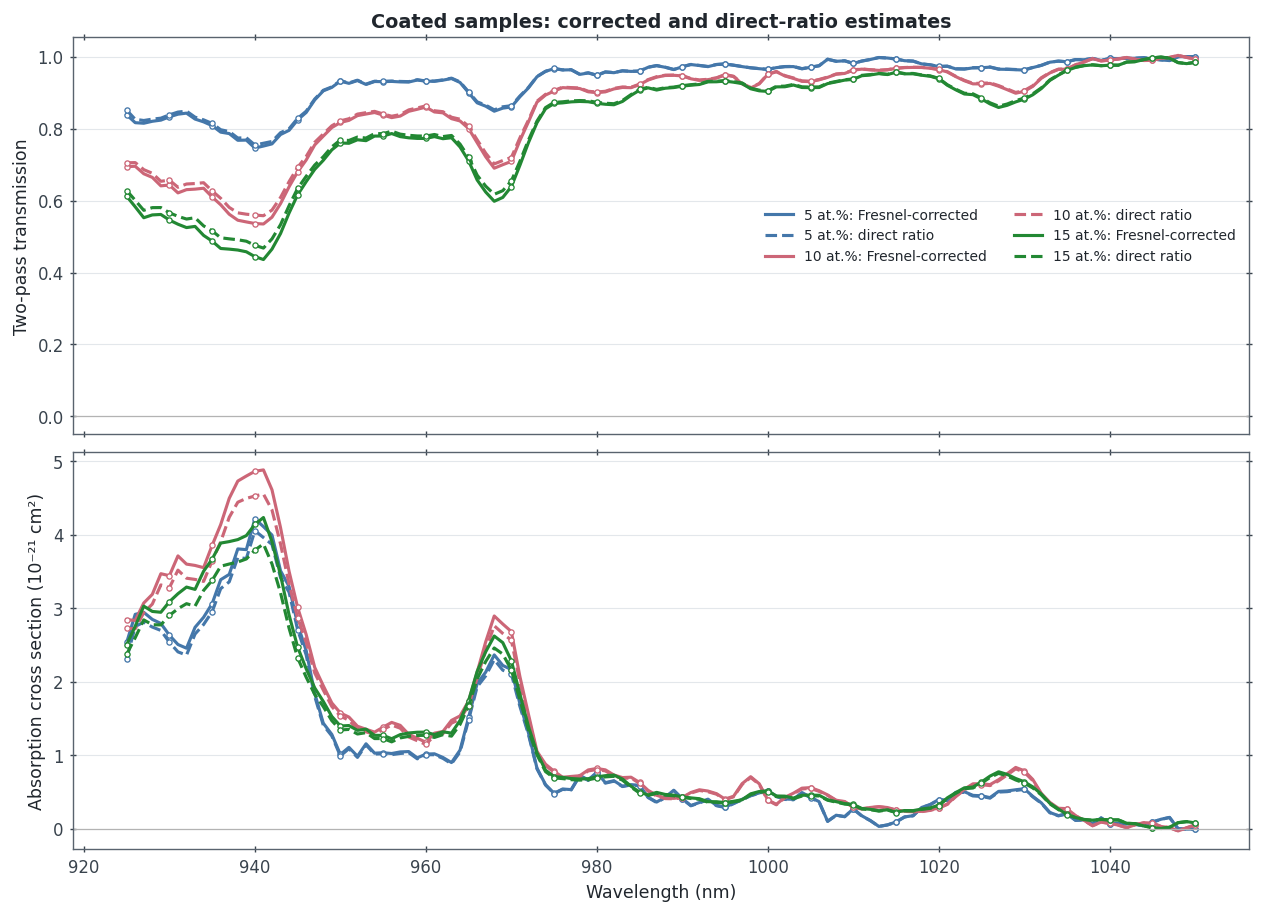

,Yb (at.%),Wavelength (nm),Corrected σ (10⁻²¹ cm²),Direct-ratio σ (10⁻²¹ cm²),Direct-ratio difference (%)
0,5,941.0,4.108,3.959,-3.613
1,5,969.0,2.221,2.157,-2.880
2,5,1030.0,0.546,0.537,-1.632
3,10,941.0,4.878,4.550,-6.725
4,10,969.0,2.784,2.656,-4.602
5,10,1030.0,0.790,0.772,-2.348
6,15,941.0,4.231,3.872,-8.502
7,15,969.0,2.531,2.376,-6.135
8,15,1030.0,0.641,0.623,-2.797


In [13]:
simple_ratio_spectra = {}
for concentration, frame in spectra.items():
    comparison = frame[["wavelength_nm", "R_open", "R_coated", "T_two_pass", "sigma_abs_cm2"]].copy()
    comparison["raw_face_ratio"] = comparison.R_open / comparison.R_coated
    off_band = comparison.query("1060 <= wavelength_nm <= 1100")
    continuum_ratio = float(off_band.raw_face_ratio.median())
    comparison["T_two_pass_simple"] = comparison.raw_face_ratio / continuum_ratio
    comparison["tau_two_pass_simple"] = -np.log(
        comparison.T_two_pass_simple.where(comparison.T_two_pass_simple > 0)
    )
    thickness_cm = THICKNESS_UM[concentration] * 1e-4
    ion_density = YB_ION_DENSITY_PER_AT_PERCENT * concentration
    comparison["alpha_simple_cm_inverse"] = comparison.tau_two_pass_simple / (2 * thickness_cm)
    comparison["sigma_simple_cm2"] = comparison.alpha_simple_cm_inverse / ion_density
    simple_ratio_spectra[concentration] = comparison

fig, axes = plt.subplots(2, 1, figsize=(10, 7.2), sharex=True, constrained_layout=True)
for concentration, comparison in simple_ratio_spectra.items():
    subset = comparison.query("925 <= wavelength_nm <= 1050")
    color = COLORS[concentration]
    axes[0].plot(subset.wavelength_nm, subset.T_two_pass, color=color,
                 label=f"{concentration} at.%: Fresnel-corrected")
    axes[0].plot(subset.wavelength_nm, subset.T_two_pass_simple, color=color,
                 linestyle="--", label=f"{concentration} at.%: direct ratio")
    axes[1].plot(subset.wavelength_nm, subset.sigma_abs_cm2 / 1e-21, color=color)
    axes[1].plot(subset.wavelength_nm, subset.sigma_simple_cm2 / 1e-21,
                 color=color, linestyle="--")
axes[0].set(ylabel="Two-pass transmission", title="Coated samples: corrected and direct-ratio estimates")
axes[1].set(xlabel="Wavelength (nm)", ylabel="Absorption cross section (10⁻²¹ cm²)")
axes[0].legend(ncol=2, fontsize=8)
for axis in axes:
    axis.axhline(0, color="0.7", linewidth=0.7)
save_figure(fig, "12_simple_ratio_comparison")
plt.show()

comparison_rows = []
for concentration, comparison in simple_ratio_spectra.items():
    for target_nm in (941, 969, 1030):
        row = comparison.iloc[(comparison.wavelength_nm - target_nm).abs().argmin()]
        main_sigma = float(row.sigma_abs_cm2 / 1e-21)
        simple_sigma = float(row.sigma_simple_cm2 / 1e-21)
        comparison_rows.append({
            "Yb (at.%)": concentration,
            "Wavelength (nm)": float(row.wavelength_nm),
            "Corrected σ (10⁻²¹ cm²)": main_sigma,
            "Direct-ratio σ (10⁻²¹ cm²)": simple_sigma,
            "Direct-ratio difference (%)": 100 * (simple_sigma / main_sigma - 1),
        })
display(pd.DataFrame(comparison_rows).round(3))

## Report

The supplied coated thicknesses are **502 µm (5 at.%), 463 µm (10 at.%), and 472 µm (15 at.%)**. Edit `THICKNESS_UM` above if these values change. The uncoated A3 transmission is assigned **509 µm and nominal 5 at.%** from the user's latest values. The uncoated A3 transmission is assigned **509 µm and nominal 5 at.%** from the user's latest values. The uncoated A3 transmission is assigned **509 µm and nominal 5 at.%** from the user's latest values.

### Reflection spectra

Al-reference and gain-corrected reflectance for the open and coated faces. This is not an absolute mirror calibration.

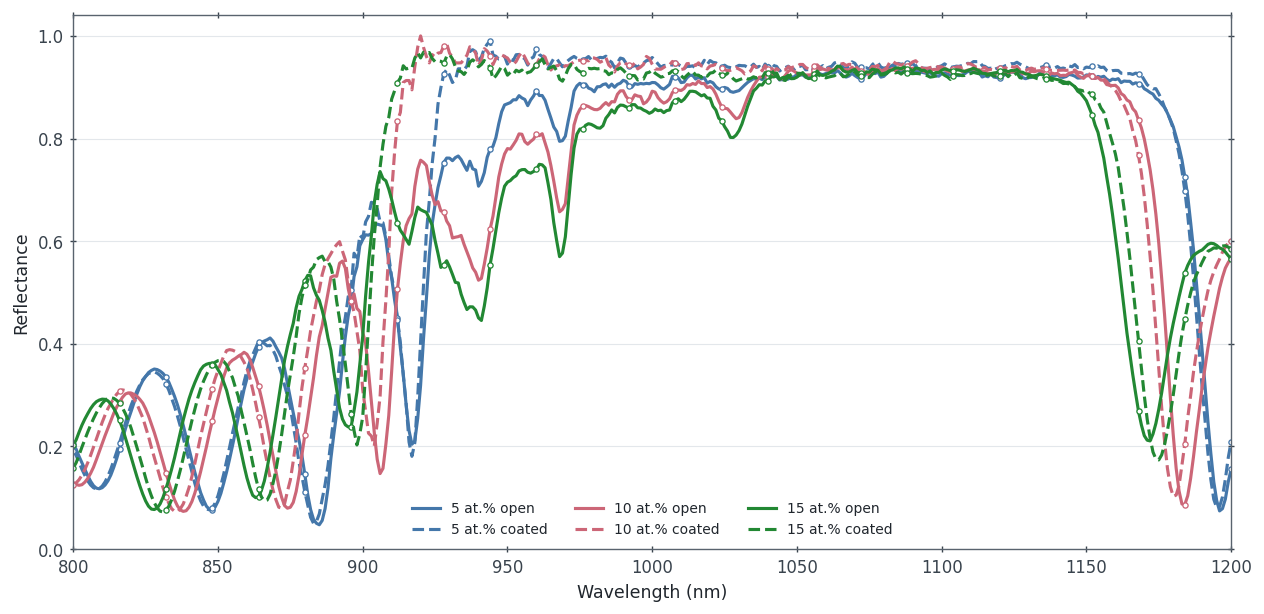

In [14]:
fig, axis = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for concentration, frame in corrected.items():
    open_side, coated_side = OPEN_AND_COATED_SIDES[concentration]
    axis.plot(frame.wavelength_nm, frame.R_open, color=COLORS[concentration],
              label=f"{concentration} at.% open")
    axis.plot(frame.wavelength_nm, frame.R_coated, "--", color=COLORS[concentration],
              label=f"{concentration} at.% coated")
axis.set(xlabel="Wavelength (nm)", ylabel="Reflectance",
         xlim=(800, 1200), ylim=(0, 1.04))
axis.legend(ncol=3, fontsize=8)
save_figure(fig, "report_reflection_spectra")
plt.show()

### Absorption spectra

One-pass absorption coefficient for coated samples and A3.

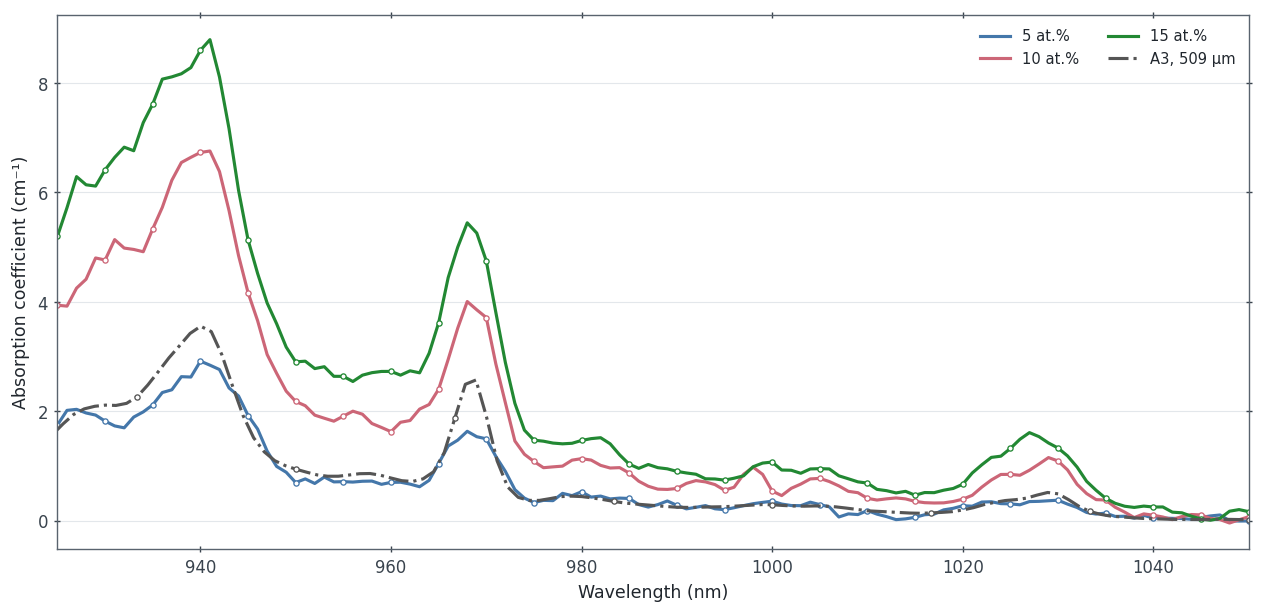

In [15]:
fig, axis = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    axis.plot(subset.wavelength_nm, subset.alpha_one_pass_cm_inverse,
              color=COLORS[concentration], label=f"{concentration} at.%")
axis.plot(pure_wavelength, a3_alpha_cm_inverse, color="#555555",
          linestyle="-.", label=f"A3, {A3_THICKNESS_MM * 1000:g} µm")
axis.set(xlabel="Wavelength (nm)", ylabel="Absorption coefficient (cm⁻¹)",
         xlim=(925, 1050))
axis.legend(ncol=2)
save_figure(fig, "report_absorption_spectra")
plt.show()

### Absorption cross sections

Cross sections use the nominal Yb concentrations and thickness values entered immediately above.

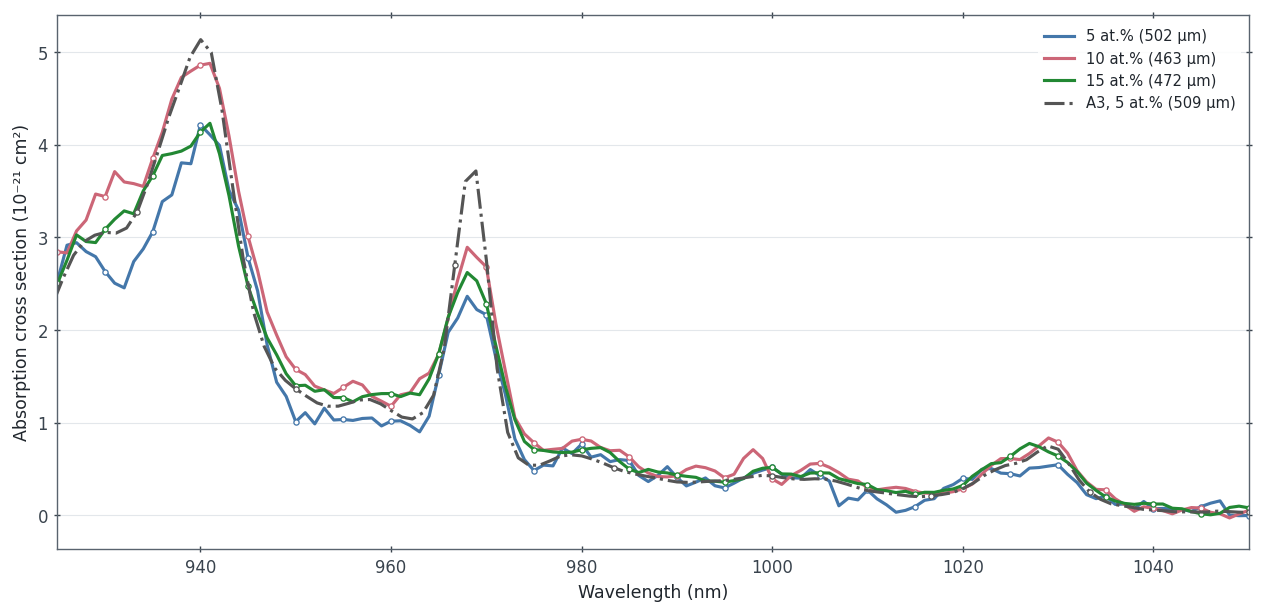

In [16]:
fig, axis = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1050")
    axis.plot(subset.wavelength_nm, frame.loc[subset.index, "sigma_abs_cm2"] / 1e-21,
              color=COLORS[concentration],
              label=f"{concentration} at.% ({THICKNESS_UM[concentration]:g} µm)")
axis.plot(pure_wavelength, a3_sigma_abs_cm2 / 1e-21, color="#555555", linestyle="-.", label=f"A3, {A3_NOMINAL_YB_AT_PERCENT:g} at.% ({A3_THICKNESS_MM * 1000:g} µm)")
axis.set(xlabel="Wavelength (nm)", ylabel="Absorption cross section (10⁻²¹ cm²)",
         xlim=(925, 1050))
axis.legend()
save_figure(fig, "report_absorption_cross_sections")
plt.show()

### Concentration inferred from A3 absorption

A3 is assigned 509 µm thickness and nominal 5 at.% Yb. The table below divides its estimated one-pass absorption coefficient by the published room-temperature cross section and `1.385×10²⁰ cm⁻³ per at.%`. These are **conditional optical concentration estimates**, not a composition assay: the Fresnel index, transparent-region gain, temperature and reference cross sections affect them. The narrow 969 nm line is particularly resolution sensitive. This calculation does acts as a consistency check; the nominal 5 at.% value is used for A3's conditional cross section.

In [17]:
concentration_rows = []
for wavelength, reference_sigma in LITERATURE_CM2.items():
    index = int(np.argmin(np.abs(pure_wavelength - wavelength)))
    alpha = float(a3_alpha_cm_inverse[index])
    concentration_rows.append({
        "wavelength_nm": wavelength,
        "A3_alpha_cm_inverse": alpha,
        "literature_sigma_1e-21_cm2": reference_sigma / 1e-21,
        "conditional_A3_Yb_at_percent": alpha / (YB_ION_DENSITY_PER_AT_PERCENT * reference_sigma),
    })
a3_concentration = pd.DataFrame(concentration_rows)
display(a3_concentration.round(3))
a3_concentration.to_csv(HERE / "A3_conditional_concentration.csv", index=False)

,wavelength_nm,A3_alpha_cm_inverse,literature_sigma_1e-21_cm2,conditional_A3_Yb_at_percent
0,941,3.459,7.890,3.165
1,969,2.574,7.604,2.444
2,1030,0.495,1.181,3.023


### Photoluminescence spectra and concentration ratios

These curves are **spectral PL measurements**, not spatial PL maps. The pinned source repository contains no pixel-positioned PL scan. The 300 K PL specimen is labeled *uncoated/unknown* in the source; its identity as A3 is unverified. Curves are normalized at ~1030 nm for shape comparison, so their heights do not compare absolute brightness. [Cleaned PL data](https://github.com/aidasmik/YbYAG/tree/d626e35938bf3ccce9c83d8cf133b6b7aa52a0a3/data/pl) and [reported ratios](https://github.com/aidasmik/YbYAG/blob/d626e35938bf3ccce9c83d8cf133b6b7aa52a0a3/data/analysis_2026_09_17/pl_concentration_ratios.csv) are copied to `pl_reference/`.

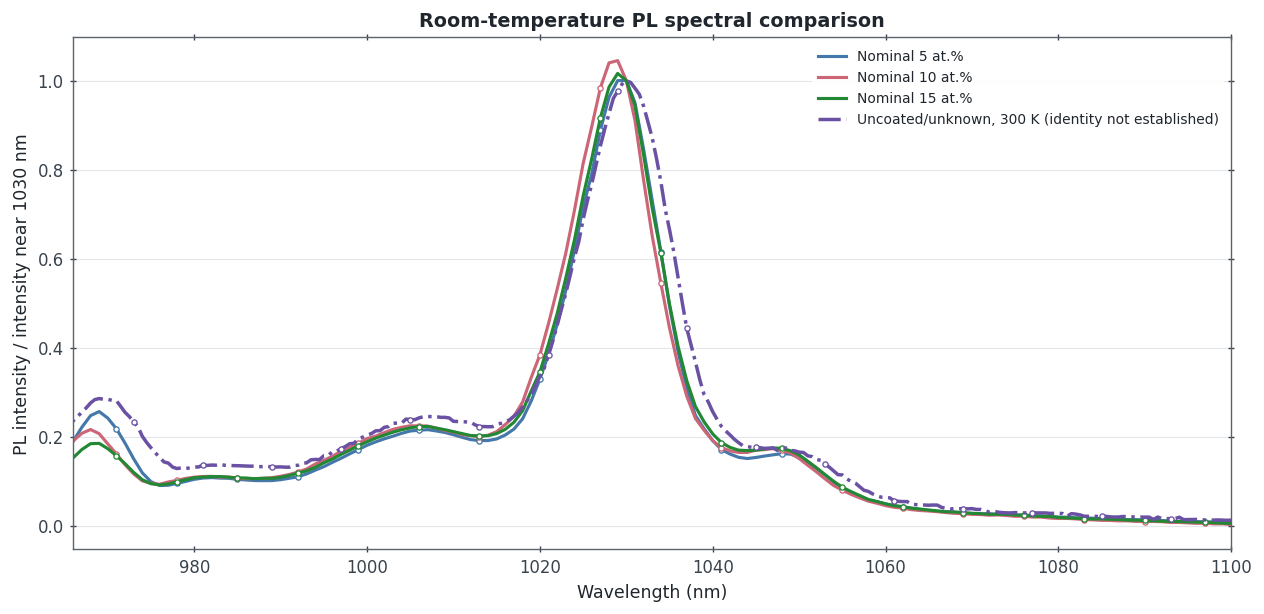

In [18]:
pl_files = {5: "5pct_Yb_PL_clean.csv", 10: "10pct_Yb_PL_clean.csv",
            15: "15pct_Yb_PL_clean.csv"}
fig, axis = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for concentration, filename in pl_files.items():
    pl = pd.read_csv(HERE / "pl_reference" / filename)
    intensity = pl.corrected_pl_arb_u.to_numpy()
    wavelengths = pl.wavelength_nm.to_numpy()
    reference = intensity[np.argmin(np.abs(wavelengths - 1030))]
    axis.plot(wavelengths, intensity / reference, color=COLORS[concentration],
              label=f"Nominal {concentration} at.%")
unknown_pl = pd.read_csv(HERE / "pl_reference" / "300K_PL_clean.csv")
unknown_wavelengths = unknown_pl.wavelength_nm.to_numpy()
unknown_intensity = unknown_pl.intensity_arb_u.to_numpy()
unknown_reference = unknown_intensity[np.argmin(np.abs(unknown_wavelengths - 1030))]
axis.plot(unknown_wavelengths, unknown_intensity / unknown_reference,
          color="#6A51A3", linestyle="-.", linewidth=2,
          label="Uncoated/unknown, 300 K (identity not established)")
axis.set(xlabel="Wavelength (nm)", ylabel="PL intensity / intensity near 1030 nm",
         xlim=(966, 1100), title="Room-temperature PL spectral comparison")
axis.legend(fontsize=8)
save_figure(fig, "report_pl_spectra")
plt.show()

### PL ratio comparison

The source reports `I(969)/I(1030)` of 0.2565, 0.2068 and 0.1851 for nominal 5, 10 and 15 at.% standards, versus 0.2857 for the uncoated/unknown specimen. The 966–972 / 1020–1040 nm integrated ratios give a second proxy. Straight-line extrapolation from only the 5 and 10 at.% standards gives roughly 2.1 and 2.4 at.% respectively for that **unknown PL specimen**. These values are secondary evidence because excitation, collection, reabsorption and temperature change PL line shapes; they are not assigned to A3.

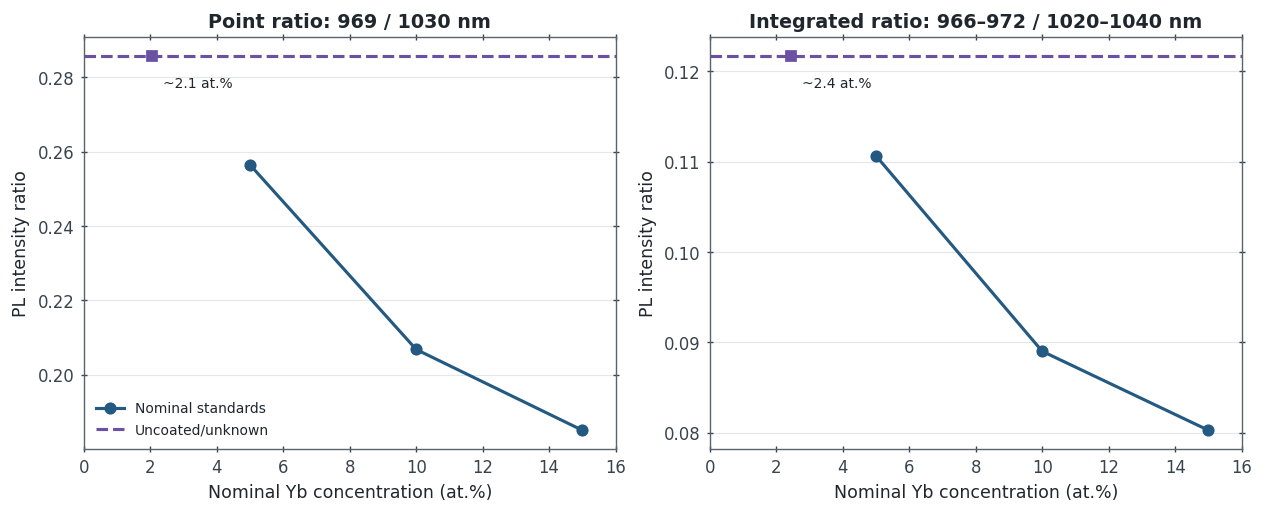

,sample,I969_I1030,band_966_972_over_1020_1040
0,nominal 5 at.%,0.2565,0.1107
1,nominal 10 at.%,0.2068,0.0890
2,nominal 15 at.%,0.1851,0.0803
3,unknown/uncoated 300 K,0.2857,0.1217


In [19]:
pl_ratios = pd.read_csv(HERE / "pl_reference" / "pl_concentration_ratios.csv")
standards = pl_ratios.iloc[:3]
unknown_ratio = pl_ratios.iloc[3]
ratio_columns = ["I969_I1030", "band_966_972_over_1020_1040"]
ratio_titles = ["Point ratio: 969 / 1030 nm",
                "Integrated ratio: 966–972 / 1020–1040 nm"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for axis, column, title in zip(axes, ratio_columns, ratio_titles):
    values = standards[column].to_numpy()
    unknown_value = float(unknown_ratio[column])
    axis.plot([5, 10, 15], values, "o-", color="#245A81", label="Nominal standards")
    axis.axhline(unknown_value, color="#6A51A3", linestyle="--",
                 label="Uncoated/unknown")
    slope = (values[1] - values[0]) / 5
    extrapolated = 5 + (unknown_value - values[0]) / slope
    axis.plot(extrapolated, unknown_value, "s", color="#6A51A3")
    axis.annotate(f"~{extrapolated:.1f} at.%", (extrapolated, unknown_value),
                  xytext=(6, -18), textcoords="offset points", fontsize=8)
    axis.set(xlabel="Nominal Yb concentration (at.%)", ylabel="PL intensity ratio",
             title=title, xlim=(0, 16))
axes[0].legend(fontsize=8)
save_figure(fig, "report_pl_concentration_ratios")
plt.show()
display(pl_ratios.round(4))

## 7. Compare with published room-temperature values

The three black markers are **point references**, not a digitized full literature curve: **941 nm, 7.89×10⁻²¹ cm²** from [Liu et al. (2007)](https://doi.org/10.1364/JOSAB.24.002081); **969 nm, 7.604×10⁻²¹ cm²** and **1030 nm, 1.181×10⁻²¹ cm²** from [Körner et al. (2012)](https://doi.org/10.1364/JOSAB.29.002493) fits as recorded in the source repository. Temperature, wavelength calibration, and instrument resolution were not independently verified for these scans.

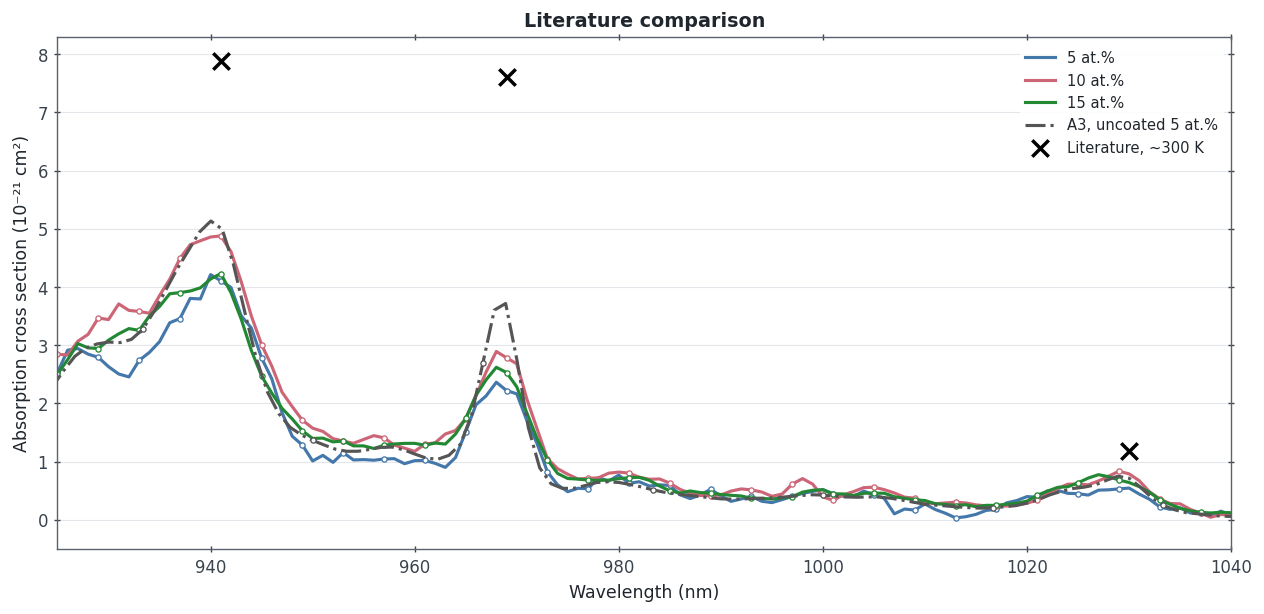

,sample,Yb_at_percent,wavelength_nm,sigma_estimate_1e-21_cm2,literature_1e-21_cm2,estimate_over_literature
0,coated 5 at.%,5.0,941,4.108,7.890,0.521
1,coated 5 at.%,5.0,969,2.221,7.604,0.292
2,coated 5 at.%,5.0,1030,0.546,1.181,0.463
3,coated 10 at.%,10.0,941,4.878,7.890,0.618
4,coated 10 at.%,10.0,969,2.784,7.604,0.366
5,coated 10 at.%,10.0,1030,0.790,1.181,0.669
6,coated 15 at.%,15.0,941,4.231,7.890,0.536
7,coated 15 at.%,15.0,969,2.531,7.604,0.333
8,coated 15 at.%,15.0,1030,0.641,1.181,0.543
9,A3,5.0,941,4.994,7.890,0.633


At 969 nm the estimate/literature ratios are [0.292, 0.366, 0.333, 0.489]


In [20]:
comparison_rows = []
fig, axis = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for concentration, frame in spectra.items():
    subset = frame.query("925 <= wavelength_nm <= 1040")
    axis.plot(subset.wavelength_nm, subset.sigma_abs_cm2 / 1e-21,
              color=COLORS[concentration], label=f"{concentration} at.%")
    for wavelength, reference in LITERATURE_CM2.items():
        measured = float(frame.loc[frame.wavelength_nm == wavelength, "sigma_abs_cm2"].iloc[0])
        comparison_rows.append({"sample": f"coated {concentration} at.%", "Yb_at_percent": concentration, "wavelength_nm": wavelength,
                                "sigma_estimate_1e-21_cm2": measured / 1e-21,
                                "literature_1e-21_cm2": reference / 1e-21,
                                "estimate_over_literature": measured / reference})
axis.plot(pure_wavelength, a3_sigma_abs_cm2 / 1e-21, color="#555555", linestyle="-.", label="A3, uncoated 5 at.%")
for wavelength, reference in LITERATURE_CM2.items():
    index = int(np.argmin(np.abs(pure_wavelength - wavelength)))
    measured = float(a3_sigma_abs_cm2[index])
    comparison_rows.append({"sample": "A3", "Yb_at_percent": A3_NOMINAL_YB_AT_PERCENT,
                            "wavelength_nm": wavelength,
                            "sigma_estimate_1e-21_cm2": measured / 1e-21,
                            "literature_1e-21_cm2": reference / 1e-21,
                            "estimate_over_literature": measured / reference})
axis.scatter(list(LITERATURE_CM2), [value / 1e-21 for value in LITERATURE_CM2.values()],
             color="black", marker="x", s=90, linewidth=2, zorder=5,
             label="Literature, ~300 K")
axis.set(xlabel="Wavelength (nm)", ylabel="Absorption cross section (10⁻²¹ cm²)",
         title="Literature comparison", xlim=(925, 1040))
axis.legend()
save_figure(fig, "11_literature_comparison")
plt.show()

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3))
print("At 969 nm the estimate/literature ratios are",
      comparison.loc[comparison.wavelength_nm == 969, "estimate_over_literature"].round(3).tolist())

### Interpretation and limits

With the supplied coated thicknesses, all three apparent cross-section curves lie below the selected literature points; changing thickness scales each sample's spectrum uniformly and cannot repair the band-specific 969 nm discrepancy. The uncoated A3 result uses its assigned 509 µm thickness and nominal 5 at.% concentration; its absorption-derived concentration estimates disagree with 5 at.% and should be treated as a consistency check. The common gain correction enforces reflectance ≤1 but does not measure the true reference mirror or coating response. Absolute cross sections require validated geometry, reference calibration, and composition.